# Векторизация текста


In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize
from gensim.models.word2vec import Word2Vec
from gensim.models.doc2vec import TaggedDocument, Doc2Vec
import gensim.downloader as api
from scipy.spatial.distance import cdist
np.random.seed(42)

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords', quiet=True)

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet', quiet=True)

sns.set_palette("husl")


Для демонстрации используем датасет **20 Newsgroups** - уже немного знакомый нам набор данных для задач текстовой классификации. Он содержит около 20,000 новостных сообщений, разделенных на 20 категорий, хорошо сбалансирован.


In [46]:
categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']

print("Загрузка данных 20 Newsgroups...")
newsgroups_train = fetch_20newsgroups(
    subset='train',
    categories=categories,
    shuffle=True,
    random_state=42,
    remove=('headers', 'footers', 'quotes')
)

newsgroups_test = fetch_20newsgroups(
    subset='test',
    categories=categories,
    shuffle=True,
    random_state=42,
    remove=('headers', 'footers', 'quotes')
)

print(f"Обучающая выборка: {len(newsgroups_train.data)} документов")
print(f"Тестовая выборка: {len(newsgroups_test.data)} документов")
print(f"Количество категорий: {len(categories)}")
print(f"\nКатегории: {categories}")


Загрузка данных 20 Newsgroups...
Обучающая выборка: 2257 документов
Тестовая выборка: 1502 документов
Количество категорий: 4

Категории: ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']


## Предобработка текста

Текст требует специальной предобработки перед использованием в моделях машинного обучения. Основные шаги:

1. **Токенизация** - разбиение текста на отдельные слова (токены)
2. **Нормализация** - приведение к нижнему регистру
3. **Удаление стоп-слов** - удаление часто встречающихся, но не несущих смысловой нагрузки слов (или мата, например)
4. **Лемматизация/Стемминг** - приведение слов к их базовой форме

Лемматизация — процесс приведения слова к его нормальной форме (лемме):
- для существительных — именительный падеж, единственное число;
- для прилагательных — именительный падеж, единственное число, мужской род; 
- для глаголов, причастий, деепричастий — глагол в инфинитиве.
Для лемматизации на русском языке есть библиотека pymorphy3.

Stemming – это процесс нахождения основы слова. В результате применения данной процедуры однокоренные слова, как правило, преобразуются к одинаковому виду. 
Snowball – фрэймворк для написания алгоритмов стемминга. Алгоритмы стемминга отличаются для разных языков и используют знания о конкретном языке – списки окончаний для разных чистей речи, разных склонений и т.д. Пример алгоритма для русского языка – Russian stemming.


In [47]:
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

example_text = newsgroups_train.data[0]
print("Исходный текст (первые 300 символов):")
print(example_text[:300])

Исходный текст (первые 300 символов):
Does anyone know of a good way (standard PC application/PD utility) to
convert tif/img/tga files into LaserJet III format.  We would also like to
do the same, converting to HPGL (HP plotter) files.

Please email any response.

Is this the correct group?

Thanks in advance.  Michael.


In [48]:
text = example_text.lower()
text = re.sub(r'[^a-zA-Z\s]', '', text)
tokens = word_tokenize(text)
tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
print(tokens)

['anyone', 'know', 'good', 'way', 'standard', 'applicationpd', 'utility', 'convert', 'tifimgtga', 'files', 'laserjet', 'iii', 'format', 'would', 'also', 'like', 'converting', 'hpgl', 'plotter', 'files', 'please', 'email', 'response', 'correct', 'group', 'thanks', 'advance', 'michael']


In [49]:
tokens = [lemmatizer.lemmatize(word) for word in tokens]
print(tokens)

['anyone', 'know', 'good', 'way', 'standard', 'applicationpd', 'utility', 'convert', 'tifimgtga', 'file', 'laserjet', 'iii', 'format', 'would', 'also', 'like', 'converting', 'hpgl', 'plotter', 'file', 'please', 'email', 'response', 'correct', 'group', 'thanks', 'advance', 'michael']


In [50]:
tokens = [stemmer.stem(word) for word in tokens]
print(tokens)

['anyon', 'know', 'good', 'way', 'standard', 'applicationpd', 'util', 'convert', 'tifimgtga', 'file', 'laserjet', 'iii', 'format', 'would', 'also', 'like', 'convert', 'hpgl', 'plotter', 'file', 'pleas', 'email', 'respons', 'correct', 'group', 'thank', 'advanc', 'michael']


In [51]:

def preprocess_text(text: str, use_lemmatization: bool = True) -> str:
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    
    if use_lemmatization:
        tokens = [lemmatizer.lemmatize(word) for word in tokens]
    else:
        tokens = [stemmer.stem(word) for word in tokens]
    
    return ' '.join(tokens)

print("После предобработки:")
processed = preprocess_text(example_text)
print(processed[:300])


После предобработки:
anyone know good way standard applicationpd utility convert tifimgtga file laserjet iii format would also like converting hpgl plotter file please email response correct group thanks advance michael


##  Векторизация текста
ML модели работают с числовыми данными, поэтому текст нужно преобразовать в числовые векторы. Рассмотрим несколько основных подходов:

**Bag-of-Words** - простейший способ представления текста. Каждый документ в нем представляется как вектор, где каждая позиция соответствует определенному слову из словаря, а значение - частоте появления этого слова в документе.
Это наиболее простой метод, но он приводит к потере информации о порядке слов и приводит к очень разреженным векторам.



In [52]:
print("Предобработка текстов...")
X_train_processed = [preprocess_text(text) for text in newsgroups_train.data[:1000]]
X_test_processed = [preprocess_text(text) for text in newsgroups_test.data[:500]]

print(f"Обработано {len(X_train_processed)} обучающих и {len(X_test_processed)} тестовых документов")


Предобработка текстов...
Обработано 1000 обучающих и 500 тестовых документов


In [53]:
bow_vectorizer = CountVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.95
)

print("Создание Bag-of-Words представления...")
X_train_bow = bow_vectorizer.fit_transform(X_train_processed)
X_test_bow = bow_vectorizer.transform(X_test_processed)

print(f"Размерность обучающей выборки: {X_train_bow.shape}")
print(f"Размерность тестовой выборки: {X_test_bow.shape}")
print(f"Размер словаря: {len(bow_vectorizer.vocabulary_)}")

print(f"\nПримеры слов из словаря (первые 20):")
print(list(bow_vectorizer.vocabulary_.keys())[:20])


Создание Bag-of-Words представления...
Размерность обучающей выборки: (1000, 5000)
Размерность тестовой выборки: (500, 5000)
Размер словаря: 5000

Примеры слов из словаря (первые 20):
['anyone', 'know', 'good', 'way', 'standard', 'utility', 'convert', 'file', 'iii', 'format', 'would', 'also', 'like', 'converting', 'plotter', 'please', 'email', 'response', 'correct', 'group']


In [54]:
doc_vector = X_train_bow[0].toarray()[0]
non_zero_indices = np.where(doc_vector > 0)[0]

print(f"Документ содержит {len(non_zero_indices)} уникальных слов из словаря")
print(f"Общее количество слов в документе: {doc_vector.sum()}")

feature_names = bow_vectorizer.get_feature_names_out()
top_words_idx = np.argsort(doc_vector)[-10:][::-1]
print("\nТоп-10 слов в документе:")
for idx in top_words_idx:
    if doc_vector[idx] > 0:
        print(f"  {feature_names[idx]}: {int(doc_vector[idx])}")


Документ содержит 23 уникальных слов из словаря
Общее количество слов в документе: 24

Топ-10 слов в документе:
  file: 2
  thanks: 1
  converting: 1
  anyone: 1
  plotter: 1
  advance: 1
  would: 1
  response: 1
  please: 1
  like: 1


**Задание**:  Постройте bag-of-words для слов без лемматизации и стемминга (а также только с лемматизацией). Как их отсутствие повлияет на размеры словаря (попробуйте не обрезать) и встречаемость слов?

In [55]:
categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']

newsgroups_train = fetch_20newsgroups(
    subset='train',
    categories=categories,
    shuffle=True,
    random_state=42,
    remove=('headers', 'footers', 'quotes')
)

newsgroups_test = fetch_20newsgroups(
    subset='test',
    categories=categories,
    shuffle=True,
    random_state=42,
    remove=('headers', 'footers', 'quotes')
)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_basic(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    return ' '.join(tokens)

def preprocess_lemmatize(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(tokens)

X_train_basic = [preprocess_basic(text) for text in newsgroups_train.data[:1000]]
X_test_basic = [preprocess_basic(text) for text in newsgroups_test.data[:500]]

X_train_lem = [preprocess_lemmatize(text) for text in newsgroups_train.data[:1000]]
X_test_lem = [preprocess_lemmatize(text) for text in newsgroups_test.data[:500]]

bow_basic = CountVectorizer()
X_train_bow_basic = bow_basic.fit_transform(X_train_basic)
X_test_bow_basic = bow_basic.transform(X_test_basic)

bow_lem = CountVectorizer()
X_train_bow_lem = bow_lem.fit_transform(X_train_lem)
X_test_bow_lem = bow_lem.transform(X_test_lem)

print(f"Размер словаря без лемматизации/стемминга: {len(bow_basic.vocabulary_)}")
print(f"Размер словаря с лемматизацией: {len(bow_lem.vocabulary_)}")

word = 'computer'
count_basic = bow_basic.vocabulary_.get(word, 0)
count_lem = bow_lem.vocabulary_.get(word, 0)
print(f"Слово '{word}' встречается: без обработки={count_basic}, с лемматизацией={count_lem}")

word_forms = ['compute', 'computes', 'computing', 'computation']
for w in word_forms:
    cnt = bow_basic.vocabulary_.get(w, 0)
    print(f"'{w}' в словаре без обработки: {cnt}")

lem_form = bow_lem.vocabulary_.get('compute', 0)
print(f"'compute' в словаре с лемматизацией: {lem_form}")

Размер словаря без лемматизации/стемминга: 18127
Размер словаря с лемматизацией: 16367
Слово 'computer' встречается: без обработки=3105, с лемматизацией=2804
'compute' в словаре без обработки: 3103
'computes' в словаре без обработки: 0
'computing' в словаре без обработки: 3109
'computation' в словаре без обработки: 3100
'compute' в словаре с лемматизацией: 2802


### TF-IDF (Term Frequency-Inverse Document Frequency)

**TF-IDF** - более продвинутый способ векторизации, который учитывает не только частоту слова в документе, но и его важность в корпусе.

- **TF (Term Frequency)**: частота слова в документе.

- **IDF (Inverse Document Frequency)**: обратная частота документа - мера того, насколько редким является слово в корпусе: 
$\text{IDF}(t) = \log\frac{N}{\text{df}(t)}$, где $N$ - общее количество документов, $\text{df}(t)$ - количество документов, содержащих термин $t$.

**Формула:**
$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$



In [56]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_processed)
X_test_tfidf = tfidf_vectorizer.transform(X_test_processed)

print(f"Размерность обучающей выборки: {X_train_tfidf.shape}")
print(f"Размерность тестовой выборки: {X_test_tfidf.shape}")

feature_names = tfidf_vectorizer.get_feature_names_out()
idf_values = tfidf_vectorizer.idf_

top_idf_idx = np.argsort(idf_values)[-20:][::-1]
print("\nТоп-20 слов с наибольшим IDF:")
for idx in top_idf_idx:
    print(f"  {feature_names[idx]}: IDF = {idf_values[idx]:.3f}")


Размерность обучающей выборки: (1000, 5000)
Размерность тестовой выборки: (500, 5000)

Топ-20 слов с наибольшим IDF:
  abc: IDF = 6.810
  scsi: IDF = 6.810
  sharp: IDF = 6.810
  shalala said: IDF = 6.810
  shalala: IDF = 6.810
  sgi machine: IDF = 6.810
  sexist: IDF = 6.810
  sexism: IDF = 6.810
  drs: IDF = 6.810
  serial port: IDF = 6.810
  ds: IDF = 6.810
  dsp: IDF = 6.810
  septuagint: IDF = 6.810
  dyer: IDF = 6.810
  sensing: IDF = 6.810
  sence: IDF = 6.810
  elaine: IDF = 6.810
  select: IDF = 6.810
  embarrassed: IDF = 6.810
  showcase: IDF = 6.810


In [57]:
mask = [i for i, el in enumerate(X_train_processed) if el.find("hicolor") > -1 ]

In [58]:
X_train_processed[123]

'cut limit azt efficacy suggest using drug either sequentially drug kind aid treatment cocktail combining number drug fight virus treating people azt alone doesnt happen real world anymore said mark jacobson university californiasan francisco also recent finding indicating hiv replicates rapidly lymph node infection physician may begin pushing even harder early treatment hivinfected patient new infectious disease push american medical news vol center disease control launch worldwide network track spread infectious disease detect drugresistant new strain time help prevent spread network expected cost million million essential part clinton administration health reform plan according cdc outside expert plan require cdc enhance surveillance disease united state establish facility across world track disease april nih plan begin aid drug trial earlier stage nature vol macilwain colin hicnet medical newsletter page volume number april national institute health announced start treating hivposi

Задание: Поиграйте с настройками для TF-IDF. Что будет, если не использовать idf (use_idf=False), как изменятся эмбеддинги? Что будет, если использовать sublinear_tf=True? Что будет ,если не нормализовать векторы? Можете сравнивать результаты через визуализации или численные характеристики.

In [59]:
tfidf_default = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.95, ngram_range=(1, 2))
X_train_default = tfidf_default.fit_transform(X_train_processed)
X_test_default = tfidf_default.transform(X_test_processed)

tfidf_no_idf = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.95, ngram_range=(1, 2), use_idf=False)
X_train_no_idf = tfidf_no_idf.fit_transform(X_train_processed)
X_test_no_idf = tfidf_no_idf.transform(X_test_processed)

tfidf_sublinear = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.95, ngram_range=(1, 2), sublinear_tf=True)
X_train_sublinear = tfidf_sublinear.fit_transform(X_train_processed)
X_test_sublinear = tfidf_sublinear.transform(X_test_processed)

tfidf_no_norm = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.95, ngram_range=(1, 2), norm=None)
X_train_no_norm = tfidf_no_norm.fit_transform(X_train_processed)
X_test_no_norm = tfidf_no_norm.transform(X_test_processed)

print("Нормы векторов первого документа:")
print(f"Стандартный TF-IDF (l2 норма): {np.linalg.norm(X_train_default[0].toarray()):.3f}")
print(f"Без IDF: {np.linalg.norm(X_train_no_idf[0].toarray()):.3f}")
print(f"Sublinear TF: {np.linalg.norm(X_train_sublinear[0].toarray()):.3f}")
print(f"Без нормализации: {np.linalg.norm(X_train_no_norm[0].toarray()):.3f}")

print("\nСравнение значений для слова 'computer' в первом документе:")
word_idx = list(tfidf_default.vocabulary_.keys()).index('computer') if 'computer' in tfidf_default.vocabulary_ else -1
if word_idx != -1:
    print(f"Стандартный TF-IDF: {X_train_default[0, word_idx]:.4f}")
    print(f"Без IDF: {X_train_no_idf[0, word_idx]:.4f}")
    print(f"Sublinear TF: {X_train_sublinear[0, word_idx]:.4f}")
    print(f"Без нормализации: {X_train_no_norm[0, word_idx]:.4f}")

doc1_default = X_train_default[0].toarray().flatten()
doc1_no_idf = X_train_no_idf[0].toarray().flatten()
doc1_sublinear = X_train_sublinear[0].toarray().flatten()
doc1_no_norm = X_train_no_norm[0].toarray().flatten()

print("\nСтатистики значений в векторе первого документа:")
print(f"Стандартный: min={doc1_default.min():.4f}, max={doc1_default.max():.4f}, mean={doc1_default.mean():.4f}")
print(f"Без IDF: min={doc1_no_idf.min():.4f}, max={doc1_no_idf.max():.4f}, mean={doc1_no_idf.mean():.4f}")
print(f"Sublinear TF: min={doc1_sublinear.min():.4f}, max={doc1_sublinear.max():.4f}, mean={doc1_sublinear.mean():.4f}")
print(f"Без нормализации: min={doc1_no_norm.min():.4f}, max={doc1_no_norm.max():.4f}, mean={doc1_no_norm.mean():.4f}")

from sklearn.metrics.pairwise import cosine_similarity
sim_default = cosine_similarity(X_train_default[0:1], X_train_default[1:2])[0][0]
sim_no_idf = cosine_similarity(X_train_no_idf[0:1], X_train_no_idf[1:2])[0][0]
sim_sublinear = cosine_similarity(X_train_sublinear[0:1], X_train_sublinear[1:2])[0][0]

print("\nКосинусное сходство между первым и вторым документом:")
print(f"Стандартный: {sim_default:.4f}")
print(f"Без IDF: {sim_no_idf:.4f}")
print(f"Sublinear TF: {sim_sublinear:.4f}")

Нормы векторов первого документа:
Стандартный TF-IDF (l2 норма): 1.000
Без IDF: 1.000
Sublinear TF: 1.000
Без нормализации: 24.652

Сравнение значений для слова 'computer' в первом документе:
Стандартный TF-IDF: 0.0000
Без IDF: 0.0000
Sublinear TF: 0.0000
Без нормализации: 0.0000

Статистики значений в векторе первого документа:
Стандартный: min=0.0000, max=0.2981, mean=0.0010
Без IDF: min=0.0000, max=0.3536, mean=0.0011
Sublinear TF: min=0.0000, max=0.2798, mean=0.0010
Без нормализации: min=0.0000, max=7.3493, mean=0.0252

Косинусное сходство между первым и вторым документом:
Стандартный: 0.0150
Без IDF: 0.0523
Sublinear TF: 0.0191


##  Эмбеддинги слов

**Эмбеддинги слов** (word embeddings) — плотные векторы фиксированной размерности, в которых семантически близкие слова оказываются близки в пространстве. В отличие от Bag-of-Words и TF-IDF это распределённое представление (distributed representation): векторы плотные, а не разреженные, и кодируют контекстное употребление слова.

Подробнее см. в [word_embeddings.md](word_embeddings.md).

### Word2Vec

**Word2Vec** учит векторные представления слов, предсказывая контекст по слову или слово по контексту. Варианты:

- **Skip-gram**: по центральному слову предсказываем слова в окне (контекст).
- **CBOW** (Continuous Bag of Words): по сумме векторов контекста предсказываем центральное слово.

Цель обучения — максимизация правдоподобия; на практике используют **negative sampling** (несколько случайных «негативных» слов вместо полного softmax по словарю). 

Основные параметры: `vector_size` (размерность), `window` (размер окна), `min_count`, `sg` (1 = skip-gram, 0 = CBOW), `negative` (число негативных примеров), `epochs`.

Обучим такую модель.

In [60]:
sentences = [text.split() for text in X_train_processed[:1500]]
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=5,
    sg=1,
    negative=5,
    epochs=10,
    seed=42,
)
embeddings_dict = {w: w2v_model.wv[w] for w in w2v_model.wv.index_to_key}
word_to_idx = {w: i for i, w in enumerate(w2v_model.wv.index_to_key)}

print("Примеры ближайших слов (most_similar):")
for word in ["computer", "medical", "god", "graphics", "cat", "rain", "cup"]:
    if word in w2v_model.wv:
        sim = w2v_model.wv.most_similar(word, topn=6)
        print(f"  {word}: {[t[0] for t in sim]}")


Примеры ближайших слов (most_similar):
  computer: ['graphic', 'modeling', 'idl', 'silicon', 'management', 'visualization']
  medical: ['april', 'newsletter', 'journal', 'hicnet', 'page', 'volume']
  god: ['eternal', 'allah', 'whosoever', 'wicked', 'mercy', 'perish']
  cat: ['cook', 'ingredient', 'meal', 'toxin', 'straight', 'coffee']
  cup: ['iraqi', 'hot', 'filled', 'wage', 'fell', 'assured']


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


### Doc2Vec

**Doc2Vec** даёт векторное представление целого документа (или предложения), а не среднее векторов слов. 
Алгоритмы:
- **PV-DM** (аналог CBOW для документов). Также обучается предсказание центрального слова, но на вход подается еще и вектор документа (paragraph vector). Этот вектор участвует в предсказании вместе с контекстными словами
- **PV-DBOW** (аналог skip-gram). Вход — список `TaggedDocument`: список слов + уникальный id документа. Модель учится предсказывать слова из этого документа (несколько случайных), обучается только paragraph vector.

Для документа, которого не было в обучающей выборке, готового вектора нет. Тогда делают inference:
- веса модели (векторы cлов и т.д.) фиксируют
- вводят новый вектор только для этого документа и подбирают его градиентным спуском так, чтобы по этому вектору (и при необходимости контексту) хорошо предсказывались слова документа.
В итоге получают embedding нового документа в том же пространстве, что и у обучающих документов.


In [61]:
tagged_docs = [
    TaggedDocument(words=text.split(), tags=[i]) # чтобы обучить модель, нужно получить список слов
    for i, text in enumerate(X_train_processed[:800])
]
d2v_model = Doc2Vec(vector_size=50, min_count=2, epochs=10, seed=42, dm=1)
d2v_model.build_vocab(tagged_docs)
d2v_model.train(tagged_docs, total_examples=d2v_model.corpus_count, epochs=d2v_model.epochs)

document_dict = {}
for idx, text in enumerate(X_train_processed[:20]):
    text = text.split()
    document_dict[idx] = d2v_model.dv[idx]

document_embeddings_df = pd.DataFrame.from_dict(document_dict, orient="index")
document_embeddings_df.head()


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,-0.040733,-0.012185,0.017155,-0.108327,0.036914,-0.010168,-0.034697,0.017962,0.027581,0.039682,...,0.026495,0.038593,0.069924,-0.020116,0.105556,0.012868,0.096571,0.040521,0.036444,-0.050526
1,-0.272652,-0.466644,-0.113466,-0.351701,0.172841,-0.071390,-0.184951,-0.157922,0.034695,0.343759,...,-0.091242,-0.099563,0.400103,0.085846,0.485370,0.149019,0.490567,0.456384,0.332127,-0.341489
2,-0.423065,-0.795013,-0.194911,-0.532359,0.287804,-0.095824,-0.265763,-0.251334,0.009714,0.517615,...,-0.201234,-0.175614,0.622730,0.037816,0.762643,0.235634,0.839971,0.807707,0.562061,-0.578921
3,-0.054170,-0.166702,-0.058317,-0.093070,0.010536,-0.037024,-0.044663,-0.062271,-0.011912,0.064832,...,-0.058795,-0.052759,0.113474,0.020166,0.108522,0.056197,0.136553,0.126358,0.099078,-0.087561
4,0.013737,-0.002756,0.011587,-0.015804,0.005336,-0.006752,-0.013885,0.014571,0.018285,0.005844,...,0.000492,-0.005479,-0.011015,-0.012938,0.007225,0.019289,-0.005575,0.006036,0.007087,0.017889


Найдем наиболее похожие документы на запрос (строка или слово) и выведем текст топ 3 похожих документов. Похожесть определяется косинусным расстоянием между векторами - мы можем построить расстояния между каким-то вектором и всеми из обучающего набора, минимальные расстояния будут соответствовать лучшим совпадениям. Примерно также работает RAG. Правда, чаще в поиске комбинируют поиск по эмбеддингам и текстовое расстояние с помощью алгоритма BM-25. 


In [62]:
def most_similar(vec, embeddings_df, n=5):
    # compute similarity
    doc_sim = (1-cdist(embeddings_df.values, vec, 'cosine'))

    # convert result to a date frame
    sim_df = pd.DataFrame(doc_sim, columns=["cos_sim"]).assign(
        document_id=list(embeddings_df.index)
    )

    # sort from most similar to least
    sim_df = sim_df.sort_values("cos_sim", ascending=False)
    return sim_df.head(n)


In [63]:
query = "computer graphics"

query_words = preprocess_text(query).split()
if len(query_words) == 0:
    query_words = query.split()

query_vec = d2v_model.infer_vector(query_words)

print("Query:", query)
print("\nTop-3 via d2v_model.dv.most_similar (all 800 docs):")
res_dv = d2v_model.dv.most_similar(positive=[query_vec], topn=3)
for rank, (doc_id, score) in enumerate(res_dv, start=1):
    print(f"\n#{rank} doc_id={doc_id}, cos_sim={score:.4f}")
    print(X_train_processed[int(doc_id)])

print("\nTop-3 via most_similar + cdist (all 800 docs):")
document_embeddings_all_df = pd.DataFrame(
    [d2v_model.dv[i] for i in range(len(tagged_docs))],
    index=list(range(len(tagged_docs))),
)

res_cdist_df = most_similar(query_vec.reshape(1, -1), document_embeddings_all_df, n=3)
for rank, row in enumerate(res_cdist_df.itertuples(index=False), start=1):
    doc_id = int(row.document_id)
    score = float(row.cos_sim)
    print(f"\n#{rank} doc_id={doc_id}, cos_sim={score:.4f}")
    print(X_train_processed[doc_id])

print("\nComparison (doc_id lists):")
print("dv.most_similar:", [int(doc_id) for doc_id, _ in res_dv])
print("cdist+df top3:", [int(doc_id) for doc_id in res_cdist_df.document_id.tolist()])


Query: computer graphics

Top-3 via d2v_model.dv.most_similar (all 800 docs):

#1 doc_id=400, cos_sim=0.9006
archivename graphicsresourceslistpart lastmodified computer graphic resource listing weekly posting part last change april scene generatorsgeographical datamapsdata file dems digital elevation model dems digital elevation model well cartographic data huge available spectrumxeroxcom pubmap contact lee moore webster research center xerox corp voice arpa internet moorewbstxeroxcom check also ncgiaucsbedu pubdems nfotis many file also available cdrom selled usgs scale digital line graph dlg data contains data state price call visit office menlo park reston virginia usamaps data user service division bureau census also data cdrom tso standard format derived usgs map data call info bb drdobbs march defense mapping agency cooperation counterpart agency canada australia released digital chart world dcw chart consists gigabyte reasonable quality vector data distributed four cdroms includ

### Визуализация эмбеддингов Word2Vec

Посмотрим на то, как эмбеддинги расположены в пространстве - построим 2D-проекцию векторов слов (PCA и t-SNE) по обученной модели Word2Vec.


Объясненная дисперсия PCA: 0.48467055


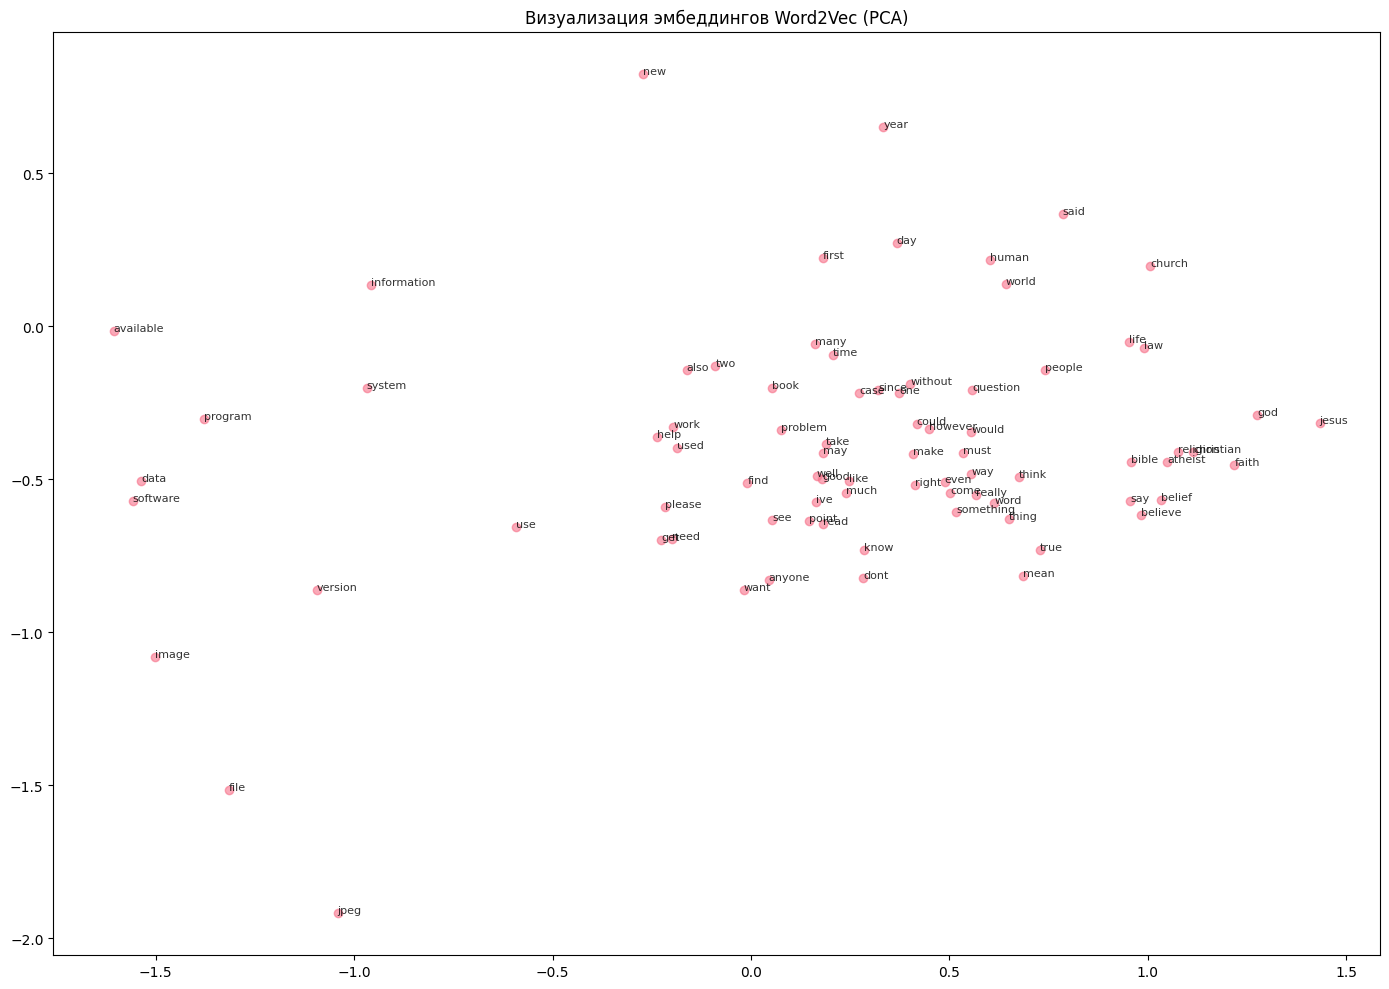

In [64]:
top_word_list = list(w2v_model.wv.index_to_key)[:80]
embeddings = np.array([w2v_model.wv[w] for w in w2v_model.wv.index_to_key]) 
embeddings = embeddings - embeddings.mean(axis=0)

pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(embeddings)
print("Объясненная дисперсия PCA:", pca.explained_variance_ratio_.sum())

fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(embeddings_2d[:len(top_word_list), 0], embeddings_2d[:len(top_word_list), 1], alpha=0.6)
for i, word in enumerate(top_word_list):
    ax.annotate(word, (embeddings_2d[i, 0], embeddings_2d[i, 1]), fontsize=8, alpha=0.8)
ax.set_title("Визуализация эмбеддингов Word2Vec (PCA)")
plt.tight_layout()
plt.show()


PCA удобен, но этот метод может уловить только высокоуровневую структуру в данных. Попробуем порисовать эмбеддинги с помощью t-SNE. Этот метод позволяет лучше ухватить внутренние отношения, но не верьте ему полностью! Подробнее в [гайде](https://distill.pub/2016/misread-tsne/). 

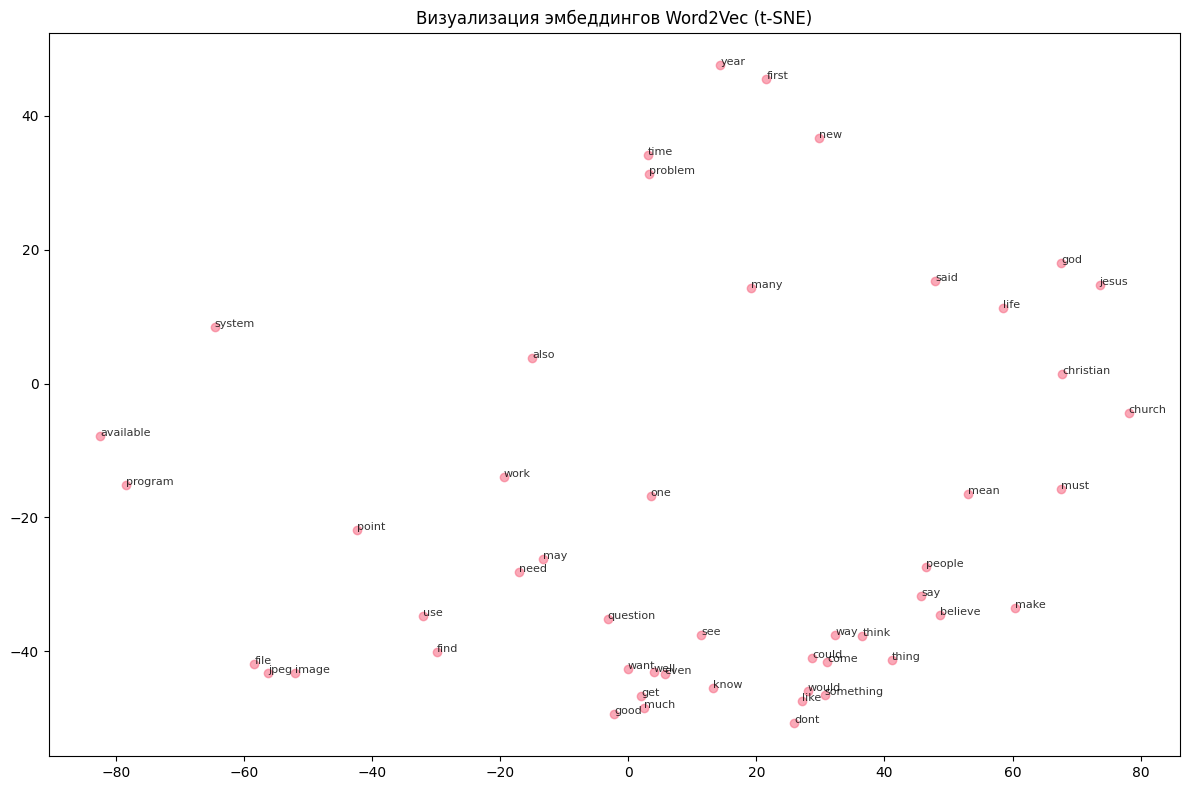

In [65]:
top_word_list_tsne = top_word_list[:50]
embeddings = np.array([w2v_model.wv[w] for w in w2v_model.wv.index_to_key]) 
embeddings = embeddings - embeddings.mean(axis=0)

tsne = TSNE(n_components=2, random_state=42, perplexity=15, max_iter=1000)
emb_tsne = tsne.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(emb_tsne[:50, 0], emb_tsne[:50, 1], alpha=0.6)
for i, word in enumerate(top_word_list_tsne):
    ax.annotate(word, (emb_tsne[i, 0], emb_tsne[i, 1]), fontsize=8, alpha=0.8)
ax.set_title("Визуализация эмбеддингов Word2Vec (t-SNE)")
plt.tight_layout()
plt.show()


In [66]:
def find_nearest_neighbors(word: str, embeddings_dict: dict[str, np.ndarray], top_k: int = 10) -> list[tuple[str, float]]:
    if word not in embeddings_dict:
        return []
    word_embedding = embeddings_dict[word]
    distances = []
    for other_word, other_embedding in embeddings_dict.items():
        if other_word == word:
            continue
        cos_sim = np.dot(word_embedding, other_embedding) / (
            np.linalg.norm(word_embedding) * np.linalg.norm(other_embedding)
        )
        distances.append((other_word, 1 - cos_sim))
    distances.sort(key=lambda x: x[1])
    return distances[:top_k]

test_words = ["computer", "medical", "god", "science", "graphics"]
print("Ближайшие соседи (Word2Vec):\n")
for word in test_words:
    if word in embeddings_dict:
        neighbors = find_nearest_neighbors(word, embeddings_dict, top_k=8)
        print(f"{word.upper()}:")
        for neighbor, dist in neighbors:
            print(f"  {neighbor}: {dist:.4f}")
        print()


Ближайшие соседи (Word2Vec):

COMPUTER:
  graphic: 0.0914
  modeling: 0.1033
  idl: 0.1183
  silicon: 0.1190
  management: 0.1218
  visualization: 0.1261
  boulder: 0.1276
  imaging: 0.1283

MEDICAL:
  april: 0.0752
  newsletter: 0.0764
  journal: 0.0873
  hicnet: 0.0875
  page: 0.1072
  volume: 0.1335
  american: 0.1614
  vol: 0.1705

GOD:
  eternal: 0.1684
  allah: 0.1696
  whosoever: 0.1788
  wicked: 0.1809
  mercy: 0.1822
  perish: 0.1838
  peace: 0.1848
  fear: 0.1853

SCIENCE:
  collection: 0.1663
  empirical: 0.1892
  basic: 0.2032
  research: 0.2400
  knowledge: 0.2466
  methodology: 0.2536
  scientific: 0.2663
  theory: 0.2714



## Эмбеддинги фраз

Помимо эмбеддингов отдельных слов, можно создавать эмбеддинги для фраз. 
Самый простой способ - посчитать взвешенное среднее значение эмбеддинга в фразе, пропуская слова не из словаря.  

In [67]:
def get_phrase_embedding(phrase: str, model) -> np.ndarray:
    kv = getattr(model, 'wv', model)
    phrase_lower = phrase.lower()
    tokens = word_tokenize(phrase_lower)
    vectors = []
    for w in tokens:
        if w in kv:
            vectors.append(kv[w])
    if not vectors:
        return np.zeros(kv.vector_size, dtype='float32')
    return np.mean(vectors, axis=0).astype('float32')

### Эмбеддинги n-грамм и их визуализация

**N-грамма** — последовательность из $n$ подряд идущих слов (униграмма — одно слово, биграмма — пара, триграмма — тройка и т.д.). Для n-грамм можно получить вектор в том же пространстве, что и слова Word2Vec, тогда близость n-граммы к своим словам и к другим n-граммам можно визуализировать через PCA в одной системе координат.

In [68]:
ngram_cv = CountVectorizer(ngram_range=(2, 2), min_df=3, max_df=0.95)
ngram_cv.fit(X_train_processed)
bigram_features = ngram_cv.get_feature_names_out()
w2v_vocab = set(w2v_model.wv.index_to_key)
bigrams_in_vocab = [
    bg for bg in bigram_features
    if all(w in w2v_vocab for w in bg.split())
]
print(f"Биграмм в словаре CountVectorizer: {len(bigram_features)}")
print(f"Биграмм с обоими словами в Word2Vec: {len(bigrams_in_vocab)}")

Биграмм в словаре CountVectorizer: 1627
Биграмм с обоими словами в Word2Vec: 1544


In [69]:
ngram_embeddings = {}
for bg in bigrams_in_vocab:
    vec = get_phrase_embedding(bg, w2v_model)
    if np.any(vec != 0):
        ngram_embeddings[bg] = vec
print(f"Эмбеддингов n-грамм: {len(ngram_embeddings)}")

Эмбеддингов n-грамм: 1544


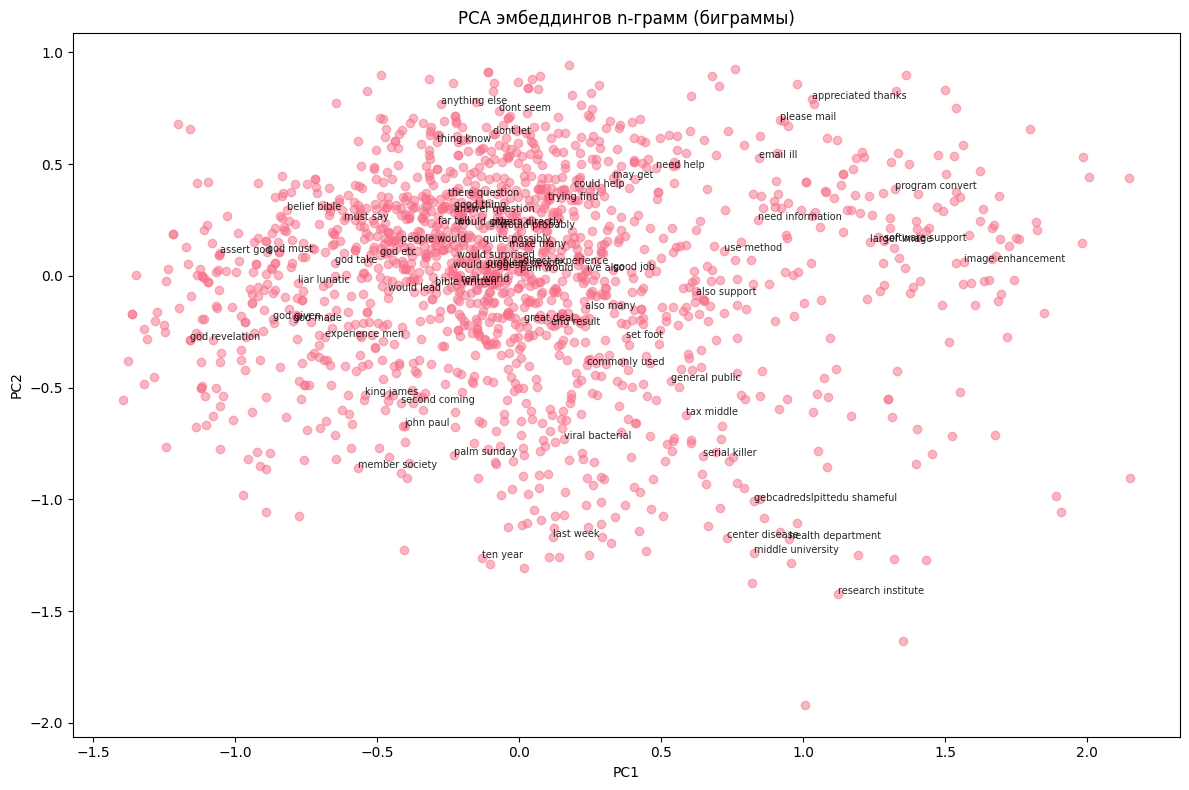

In [70]:
ngram_list = list(ngram_embeddings.keys())
ngram_matrix = np.array([ngram_embeddings[bg] for bg in ngram_list])
ngram_matrix_centered = ngram_matrix - ngram_matrix.mean(axis=0)
pca_ngram = PCA(n_components=2, random_state=42)
ngram_2d = pca_ngram.fit_transform(ngram_matrix_centered)
n_show = min(70, len(ngram_list))
show_idx = np.random.RandomState(42).choice(len(ngram_list), size=n_show, replace=False)
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(ngram_2d[:, 0], ngram_2d[:, 1], alpha=0.5)
for i in show_idx:
    ax.annotate(ngram_list[i], (ngram_2d[i, 0], ngram_2d[i, 1]), fontsize=7, alpha=0.85)
ax.set_title("PCA эмбеддингов n-грамм (биграммы)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

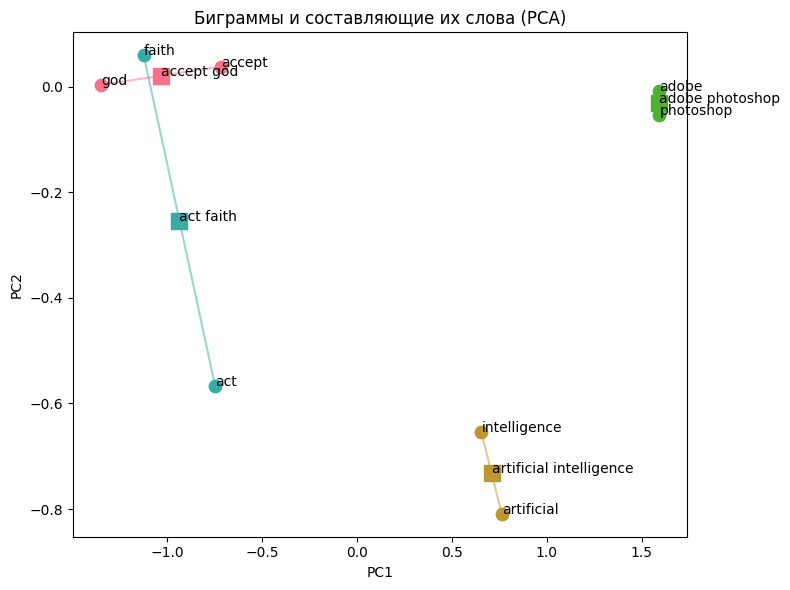

In [71]:
example_bigrams = [bg for bg in ["accept god", "artificial intelligence", "adobe photoshop", "act faith"] if bg in ngram_embeddings]
if len(example_bigrams) < 2:
    example_bigrams = ngram_list[:2]
all_vectors = []
all_labels = []
example_limits = []
for bg in example_bigrams:
    start = len(all_vectors)
    words = bg.split()
    for w in words:
        all_vectors.append(w2v_model.wv[w])
        all_labels.append(("word", w))
    all_vectors.append(ngram_embeddings[bg])
    all_labels.append(("ngram", bg))
    example_limits.append((start, len(all_vectors)))

X_ex = np.array(all_vectors)
X_ex_centered = X_ex - ngram_matrix.mean(axis=0)
coords = pca_ngram.transform(X_ex_centered)
fig, ax = plt.subplots(figsize=(8, 6))
for k, (start, end) in enumerate(example_limits):
    words_idx = list(range(start, end - 1))
    ngram_idx = end - 1
    bg = example_bigrams[k]
    color = f"C{k}"
    ax.scatter(coords[words_idx, 0], coords[words_idx, 1], c=color, s=80, zorder=2)
    ax.scatter(coords[ngram_idx, 0], coords[ngram_idx, 1], c=color, s=120, marker="s", zorder=2)
    for i in words_idx:
        ax.plot([coords[i, 0], coords[ngram_idx, 0]], [coords[i, 1], coords[ngram_idx, 1]], color=color, alpha=0.5, zorder=1)
        ax.annotate(all_labels[i][1], (coords[i, 0], coords[i, 1]), fontsize=10)
    ax.annotate(bg, (coords[ngram_idx, 0], coords[ngram_idx, 1]), fontsize=10)
ax.set_title("Биграммы и составляющие их слова (PCA)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

Биграммы кажутся осмысленными, посмотрим, так ли это с документами:

In [72]:
doc_embeddings = np.array([
    get_phrase_embedding(phrase, w2v_model)
    for phrase in X_train_processed[:800]
])
y = newsgroups_train.target[:800]


Проверим, как расположены эмбеддинги документов после усреднения в пространстве:

Объясненная дисперсия PCA для документов: 0.499


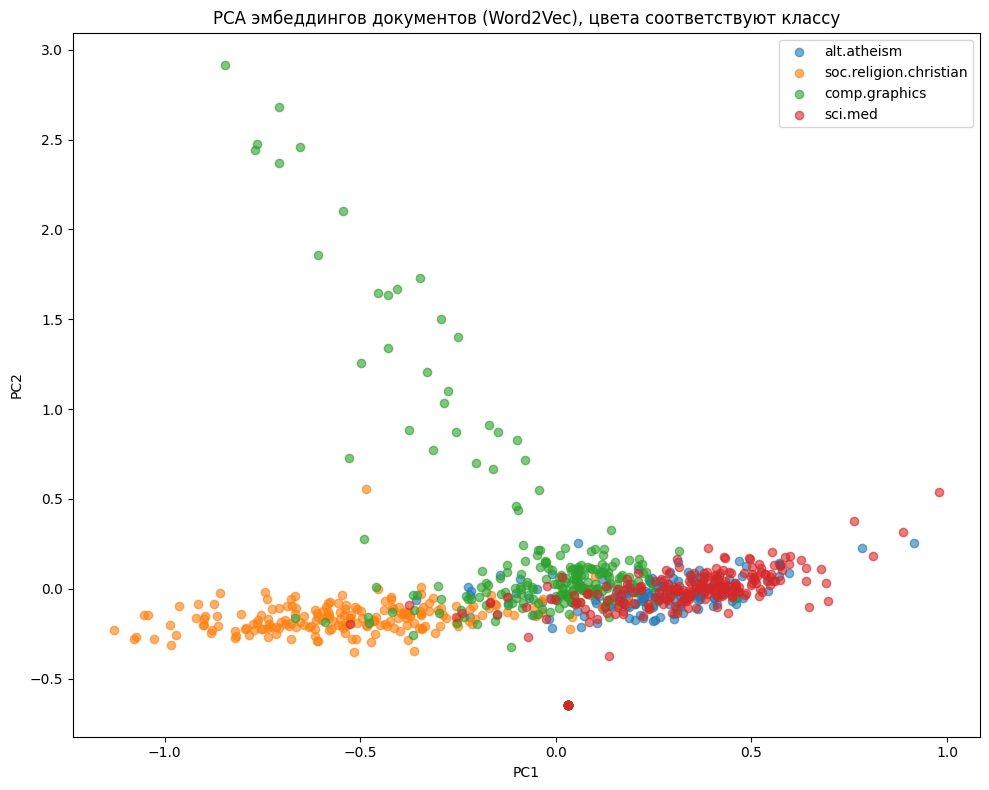

In [73]:
pca_docs = PCA(n_components=2, random_state=42)
doc_2d = pca_docs.fit_transform(doc_embeddings)

print(f"Объясненная дисперсия PCA для документов: {pca_docs.explained_variance_ratio_.sum():.3f}")

fig, ax = plt.subplots(figsize=(10, 8))

unique_labels = sorted(set(y))
colors = plt.cm.tab10.colors

for idx, label in enumerate(unique_labels):
    mask = (y == label)
    ax.scatter(
        doc_2d[mask, 0],
        doc_2d[mask, 1],
        alpha=0.6,
        color=colors[idx % len(colors)],
        label=categories[label],
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA эмбеддингов документов (Word2Vec), цвета соответствуют классу")
ax.legend()
plt.tight_layout()
plt.show()

Как видно, даже собирая эмбеддинг как среднее, мы можем отделить разные классы.

Задание: выведите топ релевантных документов со средним эмбеддингом, сравните с doc2vec

In [75]:
query = "computer graphics and visualization"
query_vec_avg = get_phrase_embedding(query, w2v_model)

doc_embeddings_full = np.array([
    get_phrase_embedding(text, w2v_model)
    for text in X_train_processed[:800]
])

similarities_w2v = cosine_similarity([query_vec_avg], doc_embeddings_full)[0]
top_w2v_idx = np.argsort(similarities_w2v)[::-1][:5]

print("Топ-5 релевантных документов (средний эмбеддинг Word2Vec):")
for rank, idx in enumerate(top_w2v_idx, 1):
    print(f"\n#{rank} doc_id={idx}, cos_sim={similarities_w2v[idx]:.4f}")
    print(X_train_processed[idx][:300])

query_tokens = preprocess_text(query).split()
if not query_tokens:
    query_tokens = query.split()
query_vec_d2v = d2v_model.infer_vector(query_tokens)
top_d2v = d2v_model.dv.most_similar(positive=[query_vec_d2v], topn=5)

print("\nТоп-5 релевантных документов (Doc2Vec):")
for rank, (doc_id, score) in enumerate(top_d2v, 1):
    print(f"\n#{rank} doc_id={doc_id}, cos_sim={score:.4f}")
    print(X_train_processed[int(doc_id)][:300])

print("\nСравнение doc_id в топ-5:")
print("Word2Vec avg:", top_w2v_idx.tolist())
print("Doc2Vec:", [int(doc_id) for doc_id, _ in top_d2v])

overlap = set(top_w2v_idx.tolist()) & set([int(doc_id) for doc_id, _ in top_d2v])
print(f"Пересечение: {len(overlap)} документов, id: {overlap}")

Топ-5 релевантных документов (средний эмбеддинг Word2Vec):

#1 doc_id=232, cos_sim=0.9241
sampe ncga university akron nasa lewis research center sponsoring computer composite oneday seminar devoted practical application computer workstation efficient processing design manufacture composite may university akron akron ohio speaker advancement graphic visualization jay horowitz nasa integra

#2 doc_id=486, cos_sim=0.9123
job opportunity serisystems engineering research institute kistkorea institute science technology looking resume following position need end june interested send resume cadcae lab floor system engineering research institute korea institute science technology yousunggu eoeundong daejon korea company 

#3 doc_id=252, cos_sim=0.9069
call presentation navy scientific visualization virtual reality seminar tuesday june carderock division naval surface warfare center formerly david taylor research center bethesda maryland sponsor ness navy engineering software system sponsoring 

## Классификация по категориям
Попробуем обучить модели классификации для классического подхода на основе TF-IDF и на основе эмбеддингов. 

In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

df_train = pd.DataFrame({
    "text": X_train_processed,
    "target": newsgroups_train.target[:1000],
})
df_test = pd.DataFrame({
    "text": X_test_processed,
    "target": newsgroups_test.target[:500],
})
y_train = df_train["target"].values
y_test = df_test["target"].values

X_train_w2v = np.array([get_phrase_embedding(t, w2v_model) for t in df_train["text"]])
X_test_w2v = np.array([get_phrase_embedding(t, w2v_model) for t in df_test["text"]])

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(df_train["text"])
X_test_tfidf = tfidf.transform(df_test["text"])

In [77]:
lr_w2v = LogisticRegression(max_iter=500, random_state=42).fit(X_train_w2v, y_train)
rf_w2v = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_w2v, y_train)
lr_tfidf = LogisticRegression(max_iter=500, random_state=42).fit(X_train_tfidf, y_train)
rf_tfidf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_tfidf, y_train)

target_names = [categories[i] for i in range(len(categories))]

def print_metrics(name: str, y_true, y_pred) -> None:
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    print("%s: acc=%.3f  precision(macro)=%.3f  recall(macro)=%.3f" % (name, acc, prec, rec))
    print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))


In [78]:

print("=== TF-IDF, LogisticRegression ===")
print_metrics("TF-IDF LR", y_test, lr_tfidf.predict(X_test_tfidf))

print("=== W2V (avg), LogisticRegression ===")
print_metrics("W2V LR", y_test, lr_w2v.predict(X_test_w2v))

=== TF-IDF, LogisticRegression ===
TF-IDF LR: acc=0.782  precision(macro)=0.784  recall(macro)=0.771
                        precision    recall  f1-score   support

           alt.atheism       0.79      0.50      0.61       107
soc.religion.christian       0.75      0.91      0.83       117
         comp.graphics       0.82      0.80      0.81       136
               sci.med       0.77      0.87      0.82       140

              accuracy                           0.78       500
             macro avg       0.78      0.77      0.77       500
          weighted avg       0.78      0.78      0.77       500

=== W2V (avg), LogisticRegression ===
W2V LR: acc=0.760  precision(macro)=0.756  recall(macro)=0.750
                        precision    recall  f1-score   support

           alt.atheism       0.68      0.50      0.57       107
soc.religion.christian       0.81      0.90      0.85       117
         comp.graphics       0.83      0.78      0.80       136
               sci.med    

In [79]:

print("=== TF-IDF, RandomForest ===")
print_metrics("TF-IDF RF", y_test, rf_tfidf.predict(X_test_tfidf))

print("=== W2V (avg), RandomForest ===")
print_metrics("W2V RF", y_test, rf_w2v.predict(X_test_w2v))

=== TF-IDF, RandomForest ===
TF-IDF RF: acc=0.698  precision(macro)=0.720  recall(macro)=0.686
                        precision    recall  f1-score   support

           alt.atheism       0.80      0.37      0.51       107
soc.religion.christian       0.62      0.89      0.73       117
         comp.graphics       0.74      0.62      0.67       136
               sci.med       0.72      0.86      0.79       140

              accuracy                           0.70       500
             macro avg       0.72      0.69      0.67       500
          weighted avg       0.72      0.70      0.68       500

=== W2V (avg), RandomForest ===
W2V RF: acc=0.750  precision(macro)=0.740  recall(macro)=0.742
                        precision    recall  f1-score   support

           alt.atheism       0.62      0.52      0.57       107
soc.religion.christian       0.79      0.88      0.83       117
         comp.graphics       0.80      0.79      0.80       136
               sci.med       0.74     

Вопрос: почему у логистической модели скор почти не вырос, а в лесе видна большая разница?

Логистическая регрессия — линейная модель, которая и так хорошо работает с разреженными признаками (TF-IDF, BoW). Для неё TF-IDF и так даёт почти оптимальное линейное разделение, а усреднённый Word2Vec сжимает семантику в плотный вектор, теряя часть информации. Случайный лес же — нелинейный ансамбль решающих деревьев. Деревьям сложно работать с тысячами разреженных признаков, каждое дерево видит лишь малую часть фич, и важные слова могут просто не попасть в сплиты. Плотные эмбеддинги (100 фич) для леса гораздо удобнее: небольшое число признаков, каждый признак семантически насыщен, дереву легко найти нелинейные комбинации. Поэтому на TF-IDF у леса низкое качество, а на W2V — большой скачок.



Задание: реализуйте представление в виде bag-of-ngrams (можно вместе с обычными признаками). Обучите классификатор на нем, сделайте выводы.

In [80]:
df_train_ngrams = pd.DataFrame({
    "text": X_train_processed,
    "target": newsgroups_train.target[:1000],
})
df_test_ngrams = pd.DataFrame({
    "text": X_test_processed,
    "target": newsgroups_test.target[:500],
})

bow_unigrams = CountVectorizer(max_features=5000)
X_train_uni = bow_unigrams.fit_transform(df_train_ngrams["text"])
X_test_uni = bow_unigrams.transform(df_test_ngrams["text"])

bow_bigrams = CountVectorizer(max_features=5000, ngram_range=(2, 2))
X_train_bi = bow_bigrams.fit_transform(df_train_ngrams["text"])
X_test_bi = bow_bigrams.transform(df_test_ngrams["text"])

bow_ngrams = CountVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_ngrams = bow_ngrams.fit_transform(df_train_ngrams["text"])
X_test_ngrams = bow_ngrams.transform(df_test_ngrams["text"])

lr_uni = LogisticRegression(max_iter=500, random_state=42).fit(X_train_uni, y_train)
lr_bi = LogisticRegression(max_iter=500, random_state=42).fit(X_train_bi, y_train)
lr_ngrams = LogisticRegression(max_iter=500, random_state=42).fit(X_train_ngrams, y_train)

rf_uni = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_uni, y_train)
rf_bi = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_bi, y_train)
rf_ngrams = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_ngrams, y_train)

print("=== Униграммы, LR ===")
print_metrics("Unigrams LR", y_test, lr_uni.predict(X_test_uni))
print("\n=== Биграммы, LR ===")
print_metrics("Bigrams LR", y_test, lr_bi.predict(X_test_bi))
print("\n=== Униграммы+Биграммы, LR ===")
print_metrics("1+2grams LR", y_test, lr_ngrams.predict(X_test_ngrams))

print("\n=== Униграммы, RF ===")
print_metrics("Unigrams RF", y_test, rf_uni.predict(X_test_uni))
print("\n=== Биграммы, RF ===")
print_metrics("Bigrams RF", y_test, rf_bi.predict(X_test_bi))
print("\n=== Униграммы+Биграммы, RF ===")
print_metrics("1+2grams RF", y_test, rf_ngrams.predict(X_test_ngrams))

=== Униграммы, LR ===
Unigrams LR: acc=0.738  precision(macro)=0.737  recall(macro)=0.735
                        precision    recall  f1-score   support

           alt.atheism       0.70      0.62      0.66       107
soc.religion.christian       0.68      0.85      0.75       117
         comp.graphics       0.77      0.67      0.72       136
               sci.med       0.80      0.80      0.80       140

              accuracy                           0.74       500
             macro avg       0.74      0.74      0.73       500
          weighted avg       0.74      0.74      0.74       500


=== Биграммы, LR ===
Bigrams LR: acc=0.498  precision(macro)=0.545  recall(macro)=0.506
                        precision    recall  f1-score   support

           alt.atheism       0.56      0.41      0.47       107
soc.religion.christian       0.40      0.84      0.54       117
         comp.graphics       0.56      0.35      0.43       136
               sci.med       0.67      0.43      

Выводы по bag-of-ngrams:

Униграммы (LR): accuracy 0.738 — хороший baseline, логистическая регрессия прекрасно справляется с отдельными словами.

Биграммы отдельно (LR и RF): accuracy падает до ~0.50 и ~0.44. Только биграмм недостаточно, модели не хватает униграммной информации, многие биграммы встречаются редко и становятся шумом.

Униграммы+биграммы (LR): accuracy 0.740 — практически не отличается от чистых униграмм. Для линейной модели добавление биграмм не даёт прироста, она и так хорошо выделяет линейные закономерности по отдельным словам.

Униграммы+биграммы (RF): accuracy 0.706 против 0.688 чистых униграмм — небольшой прирост. Лес чуть лучше использует сочетания слов, но разница минимальна.